In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [29]:
# Cargar archivo Excel
df = pd.read_excel('../data/raw/Raw_Data_Ventas.xlsx')

# Mostrar primeras filas
df.head()

,IdVenta,FechaVenta,ClienteId,ClienteNombre,Ciudad,Producto,Categoria,Cantidad,PrecioUnitario,Descuento,MetodoPago,Estado,Vendedor,EmailCliente,Telefono,TotalReportado,Observaciones_Origen
0,V-1001,2026-05-01 00:00:00,C001,Ana López,Tegucigalpa,Laptop,Tecnología,1,14500,0.05,Tarjeta,Pagado,M. Reyes,ana.lopez@example.com,9988-7766,13775.0,NaN
1,V-1001,2026-05-01 00:00:00,C001,Ana López,Tegucigalpa,Laptop,Tecnología,1,14500,0.05,Tarjeta,Pagado,M. Reyes,ana.lopez@example.com,9988-7766,13775.0,Posible duplicado exacto
2,V-1002,01/05/2026,c002,Carlos Mejía,San Pedro Sula,mouse,tecnologia,2,L. 350.00,0,efectivo,Pagado,A. Cruz,carlos.mejia@example.com,9999 1122,700.0,NaN
3,V-1003,2026/05/02,C003,María Santos,SPS,Teclado,tecnologia,1,"450,50",5%,Transferencia,pagado,A. Cruz,maria.santos@example,8888-1234,428.0,Ciudad abreviada
4,V-1004,"mayo 3, 2026",C004,Jose Rivera,La Ceiba,Monitor,Tecnología,0,3200,0,Tarjeta,Pendiente,L. Torres,jose.rivera@example.com,8877-6655,3200.0,Cantidad cero


In [30]:
# Mostrar información general del dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   IdVenta               52 non-null     str    
 1   FechaVenta            51 non-null     object 
 2   ClienteId             51 non-null     str    
 3   ClienteNombre         51 non-null     str    
 4   Ciudad                51 non-null     str    
 5   Producto              52 non-null     str    
 6   Categoria             52 non-null     str    
 7   Cantidad              51 non-null     object 
 8   PrecioUnitario        51 non-null     object 
 9   Descuento             51 non-null     object 
 10  MetodoPago            52 non-null     str    
 11  Estado                51 non-null     str    
 12  Vendedor              52 non-null     str    
 13  EmailCliente          51 non-null     str    
 14  Telefono              52 non-null     str    
 15  TotalReportado        51 non-null   

In [31]:
# Mostrar estadísticas generales
df.describe()

,TotalReportado
count,51.000000
mean,3930.549020
std,4618.437888
min,-500.000000
25%,956.250000
50%,2375.000000
75%,3900.000000
max,15000.000000


In [32]:
# Mostrar cantidad de valores nulos por columna
df.isnull().sum()

IdVenta                  0
FechaVenta               1
ClienteId                1
ClienteNombre            1
Ciudad                   1
Producto                 0
Categoria                0
Cantidad                 1
PrecioUnitario           1
Descuento                1
MetodoPago               0
Estado                   1
Vendedor                 0
EmailCliente             1
Telefono                 0
TotalReportado           1
Observaciones_Origen    15
dtype: int64

In [33]:
# Mostrar filas que contienen valores nulos
filas_nulas = df[df.isnull().any(axis=1)]

filas_nulas

,IdVenta,FechaVenta,ClienteId,ClienteNombre,Ciudad,Producto,Categoria,Cantidad,PrecioUnitario,Descuento,MetodoPago,Estado,Vendedor,EmailCliente,Telefono,TotalReportado,Observaciones_Origen
0,V-1001,2026-05-01 00:00:00,C001,Ana López,Tegucigalpa,Laptop,Tecnología,1,14500,0.05,Tarjeta,Pagado,M. Reyes,ana.lopez@example.com,9988-7766,13775.0,NaN
2,V-1002,01/05/2026,c002,Carlos Mejía,San Pedro Sula,mouse,tecnologia,2,L. 350.00,0,efectivo,Pagado,A. Cruz,carlos.mejia@example.com,9999 1122,700.0,NaN
5,V-1005,NaN,C005,Sofia García,Choloma,Silla Oficina,Muebles,3,"1,250.00",10,efectivo,Cancelado,L. Torres,sofia.garcia@example.com,3366-2211,3375.0,Fecha faltante; descuento como entero
7,V-1007,2026-05-04,NaN,Cliente Desconocido,Tegucigalpa,Impresora,Tecnología,1,3900,0,Transferencia,Pagado,A. Cruz,cliente.desconocido@example.com,9988-1111,3900.0,ClienteId faltante
15,V-1015,2026-05-08,C015,Oscar Valdez,Comayagua,Laptop,Tecnología,NaN,14500,0,Tarjeta,Pagado,L. Torres,oscar.valdez@example.com,9988-6666,NaN,Cantidad faltante
17,V-1017,2026-05-09,C017,Laura Zuniga,Tegucigalpa,Mouse,Tecnologia,2,NaN,0,Tarjeta,Pagado,M. Reyes,laura.zuniga@example.com,9988-8888,700.0,Precio no numérico
18,V-1018,2026-05-10,C018,Kevin Pinto,La Ceiba,Monitor,Tecnología,1,3200,NaN,Transferencia,Pagado,L. Torres,kevin.pinto@example.com,9988-9999,3200.0,Descuento no numérico
20,V-1020,2026-05-11,C020,Rosa Martínez,NaN,Silla Oficina,Muebles,1,1250,0,Efectivo,Pagado,M. Reyes,rosa.martinez@example.com,9966-1122,1250.0,Ciudad faltante
21,V-1021,2026-05-11,C021,Pedro Aguilar,Tegucigalpa,Tablet,Tecnología,1,5200,0.2,Tarjeta,Pagado,L. Torres,pedro.aguilar@example.com,9966-2233,4160.0,NaN
23,V-1023,2026-05-12,C023,Andrés Molina,Choloma,Audífonos,Accesorios,2,650,0,Tarjeta,Pagado,M. Reyes,andres.molina@example.com,9966-4455,1300.0,NaN


In [34]:
# Mostrar filas duplicadas
duplicados = df[df.duplicated()]

duplicados

,IdVenta,FechaVenta,ClienteId,ClienteNombre,Ciudad,Producto,Categoria,Cantidad,PrecioUnitario,Descuento,MetodoPago,Estado,Vendedor,EmailCliente,Telefono,TotalReportado,Observaciones_Origen


# Problemas encontrados

- Se encontraron valores nulos en algunas columnas.
- Existen filas duplicadas.
- Algunos datos presentan inconsistencias.
- La calidad de la data necesita limpieza antes del análisis.

In [35]:
# Eliminar filas duplicadas
df = df.drop_duplicates()

In [36]:
# Rellenar valores nulos con 0
df = df.fillna(0)

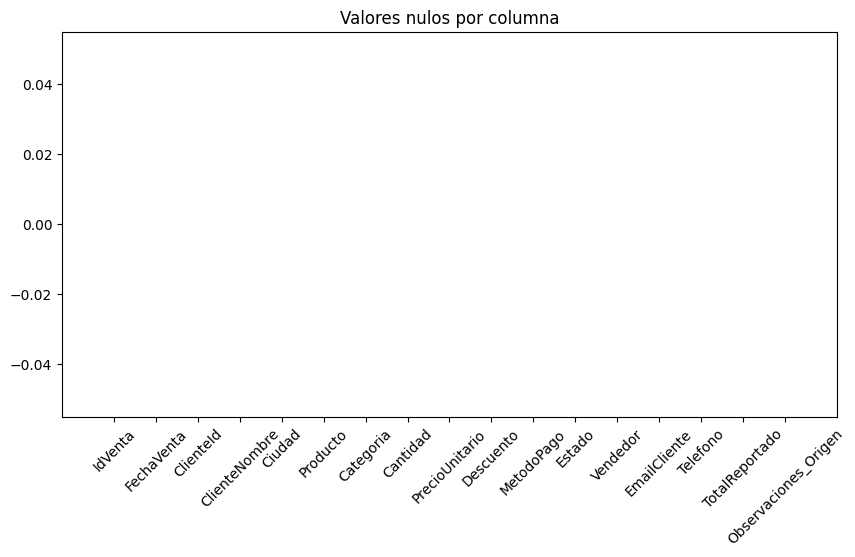

In [37]:
# Contar valores nulos por columna
nulos = df.isnull().sum()

# Crear gráfico de barras
plt.figure(figsize=(10,5))

plt.bar(nulos.index, nulos.values)

# Título del gráfico
plt.title('Valores nulos por columna')

# Rotar nombres de columnas
plt.xticks(rotation=45)

# Mostrar gráfico
plt.show()

In [38]:
# Mostrar la data limpia
df.head()

,IdVenta,FechaVenta,ClienteId,ClienteNombre,Ciudad,Producto,Categoria,Cantidad,PrecioUnitario,Descuento,MetodoPago,Estado,Vendedor,EmailCliente,Telefono,TotalReportado,Observaciones_Origen
0,V-1001,2026-05-01 00:00:00,C001,Ana López,Tegucigalpa,Laptop,Tecnología,1,14500,0.05,Tarjeta,Pagado,M. Reyes,ana.lopez@example.com,9988-7766,13775.0,0
1,V-1001,2026-05-01 00:00:00,C001,Ana López,Tegucigalpa,Laptop,Tecnología,1,14500,0.05,Tarjeta,Pagado,M. Reyes,ana.lopez@example.com,9988-7766,13775.0,Posible duplicado exacto
2,V-1002,01/05/2026,c002,Carlos Mejía,San Pedro Sula,mouse,tecnologia,2,L. 350.00,0,efectivo,Pagado,A. Cruz,carlos.mejia@example.com,9999 1122,700.0,0
3,V-1003,2026/05/02,C003,María Santos,SPS,Teclado,tecnologia,1,"450,50",5%,Transferencia,pagado,A. Cruz,maria.santos@example,8888-1234,428.0,Ciudad abreviada
4,V-1004,"mayo 3, 2026",C004,Jose Rivera,La Ceiba,Monitor,Tecnología,0,3200,0,Tarjeta,Pendiente,L. Torres,jose.rivera@example.com,8877-6655,3200.0,Cantidad cero


In [40]:
df.to_excel('../data/processed/Data_Limpia_Ventas.xlsx', index=False)